# Goal and Work Summary

**Goal**: Build and evaluate a full-image semantic segmentation pipeline to detect defects in green rough oak planks (Background, BlackRot, Knot, Stain). This notebook uses **Optuna hyperparameter optimization** to find strong training settings, then trains a **ResNet34-DeepLabV3** model and reports test-set metrics with deployment export.

## Workflow Stages and Rationale

**Stage 1 - Data audit and class normalization**
- Scan raw line-scan data and normalize class naming.
- Use reusable helpers in `notebooks/functions`.

**Why this choice**: Consistent labels improve training stability and metric reliability.

**Stage 2 - Class filtering and split preparation**
- Filter low-frequency classes using an explicit threshold.
- Build reproducible train/val/test splits.

**Why this choice**: Better class balance and repeatable experiments.

**Stage 3 - Full-image dataset and augmentations**
- Use full-image dataloading with Albumentations.
- Support non-square image sizes via `IMAGE_HEIGHT` and `IMAGE_WIDTH`.

**Why this choice**: Full context per image and configurable resolution.

**Stage 4 - Optuna hyperparameter tuning**
- Tune batch size, learning rate, weight decay, and optimizer.
- Use TPE sampler + pruning to reduce wasted trials.

**Why this choice**: Automated search usually outperforms manual tuning.

**Stage 5 - Final training with best trial**
- Train DeepLabV3 using best trial parameters.
- Save checkpoints, TensorBoard logs, and history.

**Why this choice**: Preserves reproducibility and best-model recovery.

**Stage 6 - Test-set evaluation**
- Reload best checkpoint and compute confusion matrix, pixel accuracy, F1, IoU, and ROC-AUC.

**Why this choice**: Multi-metric view captures different strengths/failures.

**Stage 7 - ONNX export and verification**
- Export EBI-compliant ONNX with baked-in preprocessing and softmax score scaling.
- Verify input/output signatures with ONNX Runtime.

**Why this choice**: Deployment-ready model artifact and quick correctness checks.

## References (Libraries)

| Library | Purpose | Link |
| --- | --- | --- |
| PyTorch | Training/inference and dataloaders | https://pytorch.org/ |
| segmentation_models_pytorch | DeepLabV3 architecture and encoders | https://github.com/qubvel/segmentation_models.pytorch |
| Optuna | Hyperparameter optimization | https://optuna.org/ |
| Albumentations | Image augmentations and normalization | https://albumentations.ai/ |
| scikit-learn | Evaluation metrics | https://scikit-learn.org/ |
| ONNX Runtime | Export verification | https://onnxruntime.ai/ |

In [ ]:
# Prepare dataset + core imports
from functions.data_pipeline import prepare_dataset
import segmentation_models_pytorch as smp
# Launch TensorBoard Session
from torch.utils.tensorboard import SummaryWriter
import optuna
from functions.oak_hf_dataset import ensure_oak_raw_data

# Change this to use a custom folder name under data/
RAW_FOLDER_NAME = "raw-data"
RAW_DIR = ensure_oak_raw_data(raw_folder_name=RAW_FOLDER_NAME)

data_root, class_mapping = prepare_dataset(
    raw_data_folder=str(RAW_DIR),
    mask_threshold=350,
    val_split=0.16,
    test_split=0.2,
)

2026-07-21 00:54:15.867374: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-21 00:54:15.904663: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-21 00:54:15.914764: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


PREPARE_DATASET — SKIPPED (data already prepared)
  Organized data: ../data/organized-data
  Classes: {'BlackRot': 1, 'Knot': 2, 'Stain': 3}
  (pass force=True to re-run the full pipeline)


In [2]:
# ──────────────────────────────────────────────
# Configuration - change these knobs as needed
# ──────────────────────────────────────────────
import torch
from datetime import datetime

GPU_ID = 0  # choose 0 or 1

if torch.cuda.is_available():
    torch.cuda.set_device(GPU_ID)           # sets the current CUDA device
    DEVICE = torch.device(f"cuda:{GPU_ID}") # use this for .to(DEVICE)
    print(f"Using GPU {GPU_ID}: {torch.cuda.get_device_name(GPU_ID)}")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU")

from pathlib import Path

MODEL_ARCH      = "DeepLabV3"
ENCODER_NAME    = "resnet34"
ENCODER_WEIGHTS = "imagenet"  # used when NOT loading a prior checkpoint

DATA_ROOT       = "../data/organized-data"
IMAGE_HEIGHT    = 384
IMAGE_WIDTH     = 1024
BATCH_SIZE      = 8
NUM_WORKERS     = 4
NUM_CLASSES     = len(class_mapping) + 1  # +1 for Background

# Remap disk mask class ids → training ids (leave {} for no remap).
# Example: alphabetical folders Knot=1, Rot=2 vs old BlackRot=1, Knot=2 → use {1: 2, 2: 1, 3: 3}
MASK_ID_REMAP   = {1:2, 2:1, 3:3}  

# ──────────────────────────────────────────────
# Transfer learning (fine-tuning) knobs
# ──────────────────────────────────────────────
# Set True when adapting a trained model to a new scanner/domain.
TRANSFER_LEARNING = True

# Path to a prior checkpoint saved by this repo (expects a dict with "model_state_dict").
# Example (prior run from this notebook):
#   "../models/DeepLabV3_FullImage_Optuna/model_best.pt"
TRANSFER_CHECKPOINT_PATH = "../models/CC_DeepLabV3_FullImage_Optuna/model_best.pt"

# Freeze encoder for a few epochs to let the head/decoder adapt first.
FREEZE_ENCODER_EPOCHS = 5

# If True, unfreeze after FREEZE_ENCODER_EPOCHS and keep training with a smaller LR.
UNFREEZE_AFTER_FREEZE = True

# LR overrides when TRANSFER_LEARNING=True (keeps fine-tuning stable).
TRANSFER_LR_FROZEN = 3e-4
TRANSFER_LR_UNFROZEN = 1e-4

# Optuna search controls
N_TRIALS        = 20
OPTUNA_DB_PATH  = "../logs/optuna/TF_STACK_DeepLabV3_FullImage_Optuna.db"
STUDY_NAME = "tf_stack_deeplabv3_fullimage_optuna"

# Final training defaults (used after selecting best trial)
LEARNING_RATE   = 1e-3
NUM_EPOCHS      = 100

CHECKPOINT_NAME = "TF_STACK_DeepLabV3_FullImage_Optuna"
LOG_NAME        = "TF_STACK_ResNet34_DeepLabV3_FullImage_Optuna"
ONNX_NAME       = "tf_stack_deeplabv3_fullimage_optuna.onnx"
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODEL_DIR = PROJECT_ROOT / "models" / CHECKPOINT_NAME

# Change this once per run/experiment
#METRICS_RUN_NAME = "stack_deeplabv3_fullimage_optuna_v1"

# Optional: auto-append timestamp so names never collide
METRICS_RUN_NAME = f"tf_cc_deeplabv3_fullimage_optuna_{datetime.now():%Y%m%d_%H%M%S}"

METRICS_DIR = PROJECT_ROOT / "data" / "metrics"
METRICS_DIR.mkdir(parents=True, exist_ok=True)

Using GPU 0: NVIDIA GeForce RTX 3090


In [3]:
from pathlib import Path
import cv2
import numpy as np
from PIL import Image
import json
import torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2


def apply_mask_id_remap(mask):
    """Map on-disk combined-mask class ids → training ids (see MASK_ID_REMAP in Configuration)."""
    remap = MASK_ID_REMAP if MASK_ID_REMAP else {}
    if not remap:
        return mask
    if isinstance(mask, torch.Tensor):
        t = mask.long()
        device = t.device
        mv = int(t.max().item()) if t.numel() else 0
        hi = max(mv, max(remap.keys()), max(remap.values()))
        lut = torch.arange(hi + 1, dtype=torch.long, device=device)
        for src, dst in remap.items():
            src, dst = int(src), int(dst)
            if 0 <= src <= hi:
                lut[src] = dst
        return lut[t].to(mask.dtype)

    arr = np.asarray(mask)
    mv = int(arr.max()) if arr.size > 0 else 0

    hi = max(mv, max(remap.keys()), max(remap.values()))
    lut = np.arange(hi + 1, dtype=np.int64)
    for src, dst in remap.items():
        src, dst = int(src), int(dst)
        if 0 <= src <= hi:
            lut[src] = dst
    mapped = lut[arr.astype(np.int64)]
    return mapped.astype(arr.dtype, copy=False)


_remap_dbg = MASK_ID_REMAP if MASK_ID_REMAP else {}
print("Training class structure (after MASK_ID_REMAP):")
print("  0: Background")
for _cls_name, _disk_id in sorted(class_mapping.items(), key=lambda kv: kv[1]):
    _train_id = int(_remap_dbg.get(_disk_id, _disk_id))
    print(f"  {_train_id}: {_cls_name}    (on-disk id {_disk_id})")


class FullImageSegmentationDataset(Dataset):
    def __init__(self, data_root, split="train", transform=None):
        self.data_root = Path(data_root)
        self.split = split
        self.transform = transform

        split_file = self.data_root / "split.json"
        with open(split_file, "r") as f:
            split_info = json.load(f)
        self.image_ids = split_info[split]

        self.images_dir = self.data_root / "images"
        self.masks_dir = self.data_root / "combined_masks"

        print(f"Loaded {split} dataset: {len(self.image_ids)} images (full image mode)")

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = self.images_dir / f"{img_id}_Col.tif"
        mask_path = self.masks_dir / f"{img_id}_mask.png"

        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path))

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        mask = apply_mask_id_remap(mask)

        return image, mask.long()


def get_training_augmentation_full(image_height=IMAGE_HEIGHT, image_width=IMAGE_WIDTH):
    aug_list = [
        A.Resize(image_height, image_width),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
        A.OneOf([A.RandomBrightnessContrast(p=1), A.RandomGamma(p=1)], p=0.3),
        A.OneOf([A.GaussNoise(p=1), A.GaussianBlur(p=1)], p=0.2),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ]
    # RandomRotate90 swaps H/W for non-square inputs and breaks batching.
    if image_height == image_width:
        aug_list.insert(3, A.RandomRotate90(p=0.5))
    return A.Compose(aug_list)


def get_validation_augmentation_full(image_height=IMAGE_HEIGHT, image_width=IMAGE_WIDTH):
    return A.Compose([
        A.Resize(image_height, image_width),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])


def create_dataloaders_full(
    data_root,
    batch_size=BATCH_SIZE,
    num_workers=4,
    image_height=IMAGE_HEIGHT,
    image_width=IMAGE_WIDTH,
):
    train_dataset = FullImageSegmentationDataset(
        data_root=data_root,
        split="train",
        transform=get_training_augmentation_full(image_height=image_height, image_width=image_width),
    )
    val_dataset = FullImageSegmentationDataset(
        data_root=data_root,
        split="val",
        transform=get_validation_augmentation_full(image_height=image_height, image_width=image_width),
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=True,
    )
    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )
    return train_loader, val_loader

Training class structure (after MASK_ID_REMAP):
  0: Background
  2: BlackRot    (on-disk id 1)
  1: Knot    (on-disk id 2)
  3: Stain    (on-disk id 3)


In [4]:
# Runtime setup (DEVICE set in Configuration cell above)

# Build class names by TRAINING id (after MASK_ID_REMAP), not disk id.
# This keeps confusion matrix / ROC labels aligned with remapped targets.
inv_train = {}
for name, disk_id in class_mapping.items():
    train_id = int(MASK_ID_REMAP.get(disk_id, disk_id)) if MASK_ID_REMAP else int(disk_id)
    if train_id in inv_train:
        raise ValueError(
            f"MASK_ID_REMAP collision: train_id={train_id} maps to both "
            f"{inv_train[train_id]} and {name}"
        )
    inv_train[train_id] = name

missing_train_ids = [i for i in range(1, NUM_CLASSES) if i not in inv_train]
if missing_train_ids:
    raise ValueError(
        f"Missing class names for training ids {missing_train_ids}. "
        "Check class_mapping and MASK_ID_REMAP."
    )

CLASS_NAMES = ["Background"] + [inv_train[i] for i in range(1, NUM_CLASSES)]
assert len(CLASS_NAMES) == NUM_CLASSES, (
    f"CLASS_NAMES ({len(CLASS_NAMES)}) != NUM_CLASSES ({NUM_CLASSES})"
)

print("CLASS_NAMES by training id:", {i: n for i, n in enumerate(CLASS_NAMES)})
print(f"Model architecture: {MODEL_ARCH}")
print(f"Encoder: {ENCODER_NAME}")
print(f"Image size (HxW): {IMAGE_HEIGHT}x{IMAGE_WIDTH}")
print(f"Num classes: {NUM_CLASSES}")
print(f"Optuna trials: {N_TRIALS}")

CLASS_NAMES by training id: {0: 'Background', 1: 'Knot', 2: 'BlackRot', 3: 'Stain'}
Model architecture: DeepLabV3
Encoder: resnet34
Image size (HxW): 384x1024
Num classes: 4
Optuna trials: 20


### Model Training Utilities (DeepLabV3)

In [5]:
# CUDA device is selected in the Configuration cell (GPU_ID / DEVICE).

In [6]:
import gc
import torch.nn as nn
from torch.optim import Adam, AdamW

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / CHECKPOINT_NAME
MODEL_DIR = PROJECT_ROOT / "models" / CHECKPOINT_NAME
TENSORBOARD_DIR = PROJECT_ROOT / "logs" / "tensorboard" / LOG_NAME

for d in [CHECKPOINT_DIR, MODEL_DIR, TENSORBOARD_DIR]:
    d.mkdir(parents=True, exist_ok=True)


def freeze_encoder(model):
    if hasattr(model, "encoder"):
        for p in model.encoder.parameters():
            p.requires_grad = False


def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True


def load_checkpoint_forgiving(model, checkpoint_path: str, device=DEVICE):
    """Load a prior checkpoint as best-effort.

    - Accepts checkpoints saved as {"model_state_dict": ...}.
    - Only loads keys whose tensor shapes match.
    - Prevents crashes when NUM_CLASSES differs (segmentation head mismatch).
    """
    if not checkpoint_path:
        return

    ckpt_path = Path(checkpoint_path)
    if not ckpt_path.exists():
        raise FileNotFoundError(f"TRANSFER_CHECKPOINT_PATH not found: {ckpt_path}")

    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    state = ckpt.get("model_state_dict", ckpt)

    model_state = model.state_dict()
    filtered = {}
    loaded, skipped = 0, 0

    for k, v in state.items():
        if k in model_state and hasattr(v, "shape") and v.shape == model_state[k].shape:
            filtered[k] = v
            loaded += 1
        else:
            skipped += 1

    model.load_state_dict(filtered, strict=False)
    print(f"Loaded checkpoint (forgiving): {ckpt_path} | loaded={loaded} skipped={skipped}")


def build_model(num_classes, encoder_name=ENCODER_NAME, encoder_weights=ENCODER_WEIGHTS):
    model = smp.DeepLabV3(
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=num_classes,
    )

    if TRANSFER_LEARNING:
        load_checkpoint_forgiving(model, TRANSFER_CHECKPOINT_PATH, device=DEVICE)

    return model.to(DEVICE)


def build_optimizer(params, name, lr, weight_decay):
    if name == "adamw":
        return AdamW(params, lr=lr, weight_decay=weight_decay)
    return Adam(params, lr=lr, weight_decay=weight_decay)


def compute_iou(pred, target, num_classes):
    ious = []
    for cls in range(num_classes):
        pred_mask = (pred == cls)
        target_mask = (target == cls)
        intersection = (pred_mask & target_mask).sum().float()
        union = (pred_mask | target_mask).sum().float()
        iou = intersection / (union + 1e-6)
        ious.append(iou.item())
    return np.mean(ious)


def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    num_batches = 0

    for img_patch, mask_patch in train_loader:
        img_patch = img_patch.to(device)
        mask_patch = mask_patch.to(device)

        logits = model(img_patch)
        loss = criterion(logits, mask_patch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / max(1, num_batches)


def validate(model, val_loader, criterion, device, num_classes):
    model.eval()
    total_loss = 0.0
    total_iou = 0.0
    num_batches = 0

    with torch.no_grad():
        for img_patch, mask_patch in val_loader:
            img_patch = img_patch.to(device)
            mask_patch = mask_patch.to(device)

            logits = model(img_patch)
            loss = criterion(logits, mask_patch)
            pred = torch.argmax(logits, dim=1)
            iou = compute_iou(pred, mask_patch, num_classes)

            total_loss += loss.item()
            total_iou += iou
            num_batches += 1

    return total_loss / max(1, num_batches), total_iou / max(1, num_batches)


def run_training(config, trial=None):
    train_loader, val_loader = create_dataloaders_full(
        data_root=DATA_ROOT,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        image_height=config.get("image_height", IMAGE_HEIGHT),
        image_width=config.get("image_width", IMAGE_WIDTH),
    )

    model = build_model(NUM_CLASSES)

    # Transfer learning schedule: optionally freeze encoder first.
    freeze_epochs = int(config.get("freeze_encoder_epochs", 0) or 0)
    unfreeze_after = bool(config.get("unfreeze_after_freeze", True))
    if config.get("transfer_learning") and freeze_epochs > 0:
        freeze_encoder(model)

    criterion = nn.CrossEntropyLoss()

    optimizer = build_optimizer(
        filter(lambda p: p.requires_grad, model.parameters()),
        name=config.get("optimizer", "adam"),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )

    writer = SummaryWriter(log_dir=config["log_dir"]) if config.get("log_dir") else None

    history = {"train_loss": [], "val_loss": [], "val_iou": []}
    best_val_iou = -1.0
    best_epoch = -1
    patience = config.get("early_stop_patience")
    min_delta = float(config.get("early_stop_min_delta", 0.0))
    epochs_since_improve = 0

    for epoch in range(config["num_epochs"]):
        # Unfreeze after a short warmup period (transfer learning).
        if config.get("transfer_learning") and freeze_epochs > 0 and unfreeze_after and epoch == freeze_epochs:
            unfreeze_all(model)
            optimizer = build_optimizer(
                model.parameters(),
                name=config.get("optimizer", "adam"),
                lr=float(config.get("lr_unfrozen", config["lr"])),
                weight_decay=config["weight_decay"],
            )

        train_loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_iou = validate(model, val_loader, criterion, DEVICE, NUM_CLASSES)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_iou"].append(val_iou)

        if config.get("verbose"):
            print(
                f"Epoch {epoch+1}/{config['num_epochs']} | "
                f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f}"
            )

        if writer:
            writer.add_scalar("Loss/Train", train_loss, epoch)
            writer.add_scalar("Loss/Val", val_loss, epoch)
            writer.add_scalar("IoU/Val", val_iou, epoch)

        improved = val_iou > best_val_iou + min_delta
        if improved:
            best_val_iou = val_iou
            best_epoch = epoch + 1
            epochs_since_improve = 0
            if config.get("save_checkpoints"):
                best_path = MODEL_DIR / "model_best.pt"
                torch.save(
                    {
                        "epoch": epoch + 1,
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "train_loss": train_loss,
                        "val_loss": val_loss,
                        "val_iou": val_iou,
                    },
                    best_path,
                )
                if config.get("verbose"):
                    print(f"  -> Best checkpoint saved: {best_path}")
        else:
            epochs_since_improve += 1

        if trial is not None:
            trial.report(val_iou, epoch)
            if trial.should_prune():
                if writer:
                    writer.close()
                raise optuna.exceptions.TrialPruned()

        if config.get("save_checkpoints") and ((epoch + 1) % config.get("save_interval", 5) == 0):
            ckpt_path = CHECKPOINT_DIR / f"model_epoch_{epoch+1}.pt"
            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "train_loss": train_loss,
                    "val_loss": val_loss,
                    "val_iou": val_iou,
                },
                ckpt_path,
            )
            if config.get("verbose"):
                print(f"  -> Checkpoint saved: {ckpt_path}")

        if patience is not None and epochs_since_improve >= patience:
            if config.get("verbose"):
                print(f"Early stopping at epoch {epoch+1} (best IoU={best_val_iou:.4f} at epoch {best_epoch})")
            break

    if config.get("save_checkpoints"):
        history_path = CHECKPOINT_DIR / "training_history.json"
        with open(history_path, "w") as f:
            json.dump(history, f, indent=2)
        if config.get("verbose"):
            print(f"\nTraining complete. History saved to {history_path}")

    if writer:
        writer.close()

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return best_val_iou, history

### Optuna Hyperparameter Tuning

Search for strong validation IoU over batch size, learning rate, weight decay, and optimizer choices.

In [7]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

optuna_db = Path(OPTUNA_DB_PATH)
optuna_db.parent.mkdir(parents=True, exist_ok=True)
OPTUNA_STORAGE = f"sqlite:///{optuna_db.resolve()}"


sampler = optuna.samplers.TPESampler(seed=42, multivariate=True)
pruner = optuna.pruners.MedianPruner(n_warmup_steps=3)


def objective(trial):
    config = {
        "lr": trial.suggest_float("lr", 1e-5, 3e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
        "optimizer": trial.suggest_categorical("optimizer", ["adam", "adamw"]),
        "num_epochs": 40,
        "early_stop_patience": 8,
        "early_stop_min_delta": 1e-3,
        "image_height": IMAGE_HEIGHT,
        "image_width": IMAGE_WIDTH,
        "save_checkpoints": False,
        "verbose": False,
    }
    best_val_iou, _ = run_training(config, trial=trial)
    return best_val_iou


study = optuna.create_study(
    direction="maximize",
    study_name=STUDY_NAME,
    storage=OPTUNA_STORAGE,
    load_if_exists=True,
    sampler=sampler,
    pruner=pruner,
)

study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True,
    gc_after_trial=True,
    catch=(RuntimeError,),
)

print("Best trial:")
print("  Value (val_iou):", study.best_trial.value)
print("  Params:", study.best_trial.params)

/tmp/ipykernel_60017/3758596731.py:8: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(seed=42, multivariate=True)


  0%|          | 0/20 [00:00<?, ?it/s]

/home/vscode/.local/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Loaded train dataset: 688 images (full image mode)
Loaded val dataset: 132 images (full image mode)
Loaded checkpoint (forgiving): ../models/CC_DeepLabV3_FullImage_Optuna/model_best.pt | loaded=260 skipped=0
Loaded train dataset: 688 images (full image mode)
Loaded val dataset: 132 images (full image mode)
Loaded checkpoint (forgiving): ../models/CC_DeepLabV3_FullImage_Optuna/model_best.pt | loaded=260 skipped=0
Loaded train dataset: 688 images (full image mode)
Loaded val dataset: 132 images (full image mode)
Loaded checkpoint (forgiving): ../models/CC_DeepLabV3_FullImage_Optuna/model_best.pt | loaded=260 skipped=0
Loaded train dataset: 688 images (full image mode)
Loaded val dataset: 132 images (full image mode)
Loaded checkpoint (forgiving): ../models/CC_DeepLabV3_FullImage_Optuna/model_best.pt | loaded=260 skipped=0
Loaded train dataset: 688 images (full image mode)
Loaded val dataset: 132 images (full image mode)
Loaded checkpoint (forgiving): ../models/CC_DeepLabV3_FullImage_Optu

### Train Final Model With Best Hyperparameters

Train DeepLabV3 with the selected trial and save best/periodic checkpoints.

In [8]:
best_params = study.best_trial.params

final_config = {
    "batch_size": BATCH_SIZE,
    "lr": best_params["lr"],
    "weight_decay": best_params["weight_decay"],
    "optimizer": best_params["optimizer"],
    "num_epochs": NUM_EPOCHS,
    "early_stop_patience": 10,
    "early_stop_min_delta": 1e-4,
    "image_height": IMAGE_HEIGHT,
    "image_width": IMAGE_WIDTH,
    "save_checkpoints": True,
    "save_interval": 5,
    "log_dir": str(TENSORBOARD_DIR),
    "verbose": True,
}

#best_val_iou, history = run_training(final_config)
#print(f"Final training complete. Best Val IoU: {best_val_iou:.4f}")

In [9]:
# Optional: transfer learning override for final training
# (Keeps Optuna tuning unchanged; only affects the final training run.)

if TRANSFER_LEARNING:
    final_config.update(
        {
            "transfer_learning": True,
            "freeze_encoder_epochs": FREEZE_ENCODER_EPOCHS,
            "unfreeze_after_freeze": UNFREEZE_AFTER_FREEZE,
            "lr_unfrozen": TRANSFER_LR_UNFROZEN,
        }
    )
    final_config["lr"] = TRANSFER_LR_FROZEN

    best_val_iou, history = run_training(final_config)
    print(f"Transfer-learning run complete. Best Val IoU: {best_val_iou:.4f}")


Loaded train dataset: 688 images (full image mode)
Loaded val dataset: 132 images (full image mode)
Loaded checkpoint (forgiving): ../models/CC_DeepLabV3_FullImage_Optuna/model_best.pt | loaded=260 skipped=0
Epoch 1/100 | Train Loss: 0.2539 | Val Loss: 0.2251 | Val IoU: 0.4311
  -> Best checkpoint saved: /workspaces/Oak-Defect-Detection/models/TF_STACK_DeepLabV3_FullImage_Optuna/model_best.pt
Epoch 2/100 | Train Loss: 0.2426 | Val Loss: 0.2394 | Val IoU: 0.4355
  -> Best checkpoint saved: /workspaces/Oak-Defect-Detection/models/TF_STACK_DeepLabV3_FullImage_Optuna/model_best.pt
Epoch 3/100 | Train Loss: 0.2464 | Val Loss: 0.2214 | Val IoU: 0.4810
  -> Best checkpoint saved: /workspaces/Oak-Defect-Detection/models/TF_STACK_DeepLabV3_FullImage_Optuna/model_best.pt
Epoch 4/100 | Train Loss: 0.2386 | Val Loss: 0.2413 | Val IoU: 0.4779
Epoch 5/100 | Train Loss: 0.2361 | Val Loss: 0.2138 | Val IoU: 0.4730
  -> Checkpoint saved: /workspaces/Oak-Defect-Detection/checkpoints/TF_STACK_DeepLabV3_F

In [10]:
# Create test loader
test_dataset = FullImageSegmentationDataset(
    data_root=DATA_ROOT,
    split="test",
    transform=get_validation_augmentation_full(image_height=IMAGE_HEIGHT, image_width=IMAGE_WIDTH),
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print(f"Loaded test dataset: {len(test_dataset)} images")

Loaded test dataset: 205 images (full image mode)
Loaded test dataset: 205 images


In [11]:
# Load best model for evaluation
best_model_path = MODEL_DIR / "model_best.pt"

model = smp.DeepLabV3(
    encoder_name=ENCODER_NAME,
    encoder_weights=None,
    in_channels=3,
    classes=NUM_CLASSES,
).to(DEVICE)

ckpt = torch.load(best_model_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print(f"Loaded best model: {best_model_path}")
print(f"Checkpoint epoch={ckpt.get('epoch')} | val_iou={ckpt.get('val_iou'):.4f}")

Loaded best model: /workspaces/Oak-Defect-Detection/models/TF_STACK_DeepLabV3_FullImage_Optuna/model_best.pt
Checkpoint epoch=8 | val_iou=0.5009


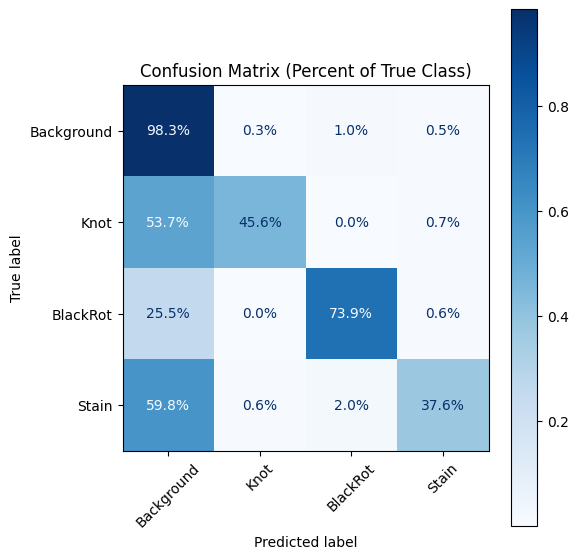

Accuracy: 0.9333
F1 per class:
  Background: 0.9640
  Knot: 0.5356
  BlackRot: 0.7686
  Stain: 0.5115
F1 Macro: 0.6949
IoU per class:
  Background: 0.9306
  Knot: 0.3657
  BlackRot: 0.6242
  Stain: 0.3436
Mean IoU (excl background): 0.4445


/tmp/ipykernel_60017/3489643509.py:81: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig_roc.tight_layout()
/tmp/ipykernel_60017/3489643509.py:84: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig_roc.savefig(roc_png, dpi=200, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


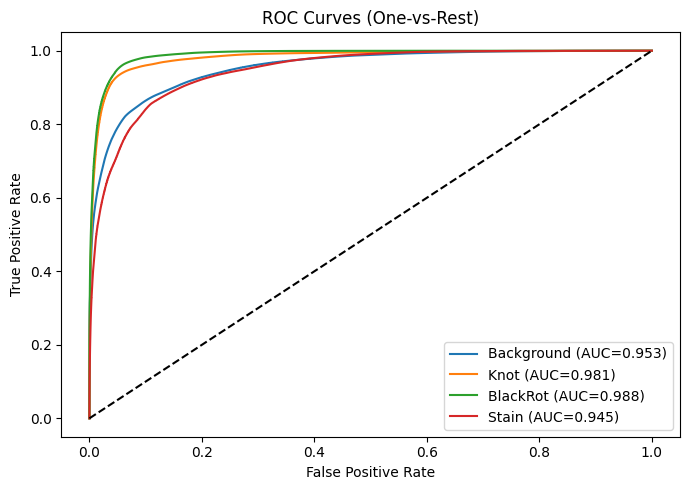

Saved confusion matrix to: /workspaces/Oak-Defect-Detection/data/metrics/tf_cc_deeplabv3_fullimage_optuna_20260721_005420_confusion_matrix.png
Saved ROC curves to: /workspaces/Oak-Defect-Detection/data/metrics/tf_cc_deeplabv3_fullimage_optuna_20260721_005420_roc_curves.png


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, roc_curve, auc
from sklearn.metrics import ConfusionMatrixDisplay

all_preds = []
all_targets = []
all_probs = []

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.append(preds.cpu().numpy().reshape(-1))
        all_targets.append(masks.cpu().numpy().reshape(-1))
        all_probs.append(probs.cpu().numpy().transpose(0, 2, 3, 1).reshape(-1, NUM_CLASSES))

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)
all_probs = np.concatenate(all_probs)

cm = confusion_matrix(all_targets, all_preds, labels=list(range(NUM_CLASSES)))
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

# Confusion matrix figure
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=CLASS_NAMES)
fig_cm, ax_cm = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax_cm, cmap="Blues", values_format=".1%", colorbar=True, xticks_rotation=45)
ax_cm.set_title("Confusion Matrix (Percent of True Class)")
fig_cm.tight_layout()

cm_png = METRICS_DIR / f"{METRICS_RUN_NAME}_confusion_matrix.png"
fig_cm.savefig(cm_png, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig_cm)

acc = accuracy_score(all_targets, all_preds)
print(f"Accuracy: {acc:.4f}")

f1_per_class = f1_score(all_targets, all_preds, labels=list(range(NUM_CLASSES)), average=None)
f1_macro = f1_score(all_targets, all_preds, labels=list(range(NUM_CLASSES)), average="macro")
print("F1 per class:")
for i, f1 in enumerate(f1_per_class):
    print(f"  {CLASS_NAMES[i]}: {f1:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")

intersection = np.diag(cm).astype(np.float32)
union = cm.sum(axis=0) + cm.sum(axis=1) - intersection
iou_per_class = np.divide(intersection, union, out=np.zeros_like(intersection), where=union != 0)
print("IoU per class:")
for i, iou in enumerate(iou_per_class):
    print(f"  {CLASS_NAMES[i]}: {iou:.4f}")

mean_iou_excl_bg = iou_per_class[1:].mean() if NUM_CLASSES > 1 else iou_per_class.mean()
print(f"Mean IoU (excl background): {mean_iou_excl_bg:.4f}")

# ROC figure
fig_roc, ax_roc = plt.subplots(figsize=(7, 5))
for c in range(NUM_CLASSES):
    y_true_bin = (all_targets == c).astype(int)
    y_score = all_probs[:, c]

    if y_true_bin.sum() == 0:
        print(f"ROC skipped: {CLASS_NAMES[c]} (no positives in test set)")
        continue

    fpr, tpr, _ = roc_curve(y_true_bin, y_score)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, label=f"{CLASS_NAMES[c]} (AUC={roc_auc:.3f})")

ax_roc.plot([0, 1], [0, 1], "k--")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curves (One-vs-Rest)")
ax_roc.legend()
fig_roc.tight_layout()

roc_png = METRICS_DIR / f"{METRICS_RUN_NAME}_roc_curves.png"
fig_roc.savefig(roc_png, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig_roc)

print(f"Saved confusion matrix to: {cm_png}")
print(f"Saved ROC curves to: {roc_png}")

In [13]:
import torch.nn.functional as F
import torch.onnx
import torch.nn as nn
import numpy as np


class EBIExportWrapper(nn.Module):
    """
    Input:  uint8  [B, 3, H, W]  (raw RGB 0-255)
    Output: float32 [B, C, H, W] (per-pixel class scores 0-100%)
    """

    def __init__(self, seg_model, mean=None, std=None):
        super().__init__()
        self.seg_model = seg_model
        if mean is None:
            mean = [0.485, 0.456, 0.406]
        if std is None:
            std = [0.229, 0.224, 0.225]
        self.register_buffer("mean", torch.tensor(mean, dtype=torch.float32).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor(std, dtype=torch.float32).view(1, 3, 1, 1))

    def forward(self, x):
        x = x.float() / 255.0
        x = (x - self.mean) / self.std
        logits = self.seg_model(x)
        probs = F.softmax(logits, dim=1)
        return probs * 100.0


onnx_dir = PROJECT_ROOT / "models" / "onnx"
onnx_dir.mkdir(parents=True, exist_ok=True)
onnx_path = onnx_dir / ONNX_NAME

ebi_model = EBIExportWrapper(model).to(DEVICE)
ebi_model.eval()

dummy_input = torch.randint(0, 256, (1, 3, IMAGE_HEIGHT, IMAGE_WIDTH), dtype=torch.uint8, device=DEVICE)

torch.onnx.export(
    ebi_model,
    dummy_input,
    onnx_path.as_posix(),
    input_names=["input"],
    output_names=["output"],
    opset_version=12,
    dynamo=False,
    dynamic_axes={
        "input": {0: "batch", 2: "height", 3: "width"},
        "output": {0: "batch", 2: "height", 3: "width"},
    },
)

print(f"Exported ONNX model to: {onnx_path}")
print("  Input:  uint8  [B, 3, H, W]  (raw RGB 0-255)")
print("  Output: float32 [B, C, H, W] (per-pixel class scores 0-100%)")

import onnxruntime as ort

session = ort.InferenceSession(onnx_path.as_posix())
inp_meta = session.get_inputs()[0]
out_meta = session.get_outputs()[0]
print(f"ONNX Input:  name={inp_meta.name}, shape={inp_meta.shape}, type={inp_meta.type}")
print(f"ONNX Output: name={out_meta.name}, shape={out_meta.shape}, type={out_meta.type}")

test_input = np.random.randint(0, 256, (1, 3, IMAGE_HEIGHT, IMAGE_WIDTH)).astype(np.uint8)
onnx_output = session.run(None, {inp_meta.name: test_input})[0]
print(f"Output range: [{onnx_output.min():.2f}, {onnx_output.max():.2f}]")
print(f"Class-sum range: min={onnx_output.sum(axis=1).min():.2f}, max={onnx_output.sum(axis=1).max():.2f}")
print("ONNX verification passed")

/tmp/ipykernel_60017/1981096469.py:40: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Exported ONNX model to: /workspaces/Oak-Defect-Detection/models/onnx/tf_stack_deeplabv3_fullimage_optuna.onnx
  Input:  uint8  [B, 3, H, W]  (raw RGB 0-255)
  Output: float32 [B, C, H, W] (per-pixel class scores 0-100%)
ONNX Input:  name=input, shape=['batch', 3, 'height', 'width'], type=tensor(uint8)
ONNX Output: name=output, shape=['batch', 4, 'height', 'width'], type=tensor(float)
Output range: [0.22, 98.78]
Class-sum range: min=100.00, max=100.00
ONNX verification passed


In [ ]:
from pathlib import Path
import sys
import json

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
notebooks_dir = project_root / "notebooks"
if str(notebooks_dir) not in sys.path:
    sys.path.append(str(notebooks_dir))

from functions.metrics_export import (
    append_row_to_csv,
    build_run_row,
    first_available,
    guess_actual_epochs,
    infer_split_sizes,
)

local_vars = locals()

history = local_vars.get("history")
training_history_path = local_vars.get("history_path")
if training_history_path is None and "CHECKPOINT_DIR" in local_vars:
    training_history_path = local_vars["CHECKPOINT_DIR"] / "training_history.json"
if history is None and training_history_path is not None and Path(training_history_path).exists():
    with open(training_history_path, "r", encoding="utf-8") as f:
        history = json.load(f)

final_config = local_vars.get("final_config", {})
optuna_best_params = final_config.copy() if isinstance(final_config, dict) else {}
if "study" in local_vars and getattr(local_vars["study"], "best_trial", None) is not None:
    optuna_best_params = dict(local_vars["study"].best_trial.params)

train_split_size, val_split_size, test_split_size = infer_split_sizes(project_root)

extra_training_params = {}
if isinstance(final_config, dict):
    for key, value in final_config.items():
        extra_training_params[key] = value

for key in [
    "ENCODER_NAME",
    "TRANSFER_LEARNING",
    "FREEZE_ENCODER_EPOCHS",
    "NUM_EPOCHS",
    "BATCH_SIZE",
    "NUM_WORKERS",
    "LEARNING_RATE",
    "OPTUNA_DB_PATH",
    "STUDY_NAME",
]:
    if key in local_vars:
        extra_training_params[key] = local_vars[key]

metrics_dir = Path(local_vars.get("METRICS_DIR", project_root / "data" / "metrics"))
csv_path = metrics_dir / "TRAINING_RESULTS_SUMMARY.csv"

row = build_run_row(
    notebook_name="DeepLabv3_FullImage_Optuna",
    model_name=str(first_available(local_vars, ["MODEL_ARCH", "CHECKPOINT_NAME"]) or "DeepLabV3"),
    raw_data_folder=first_available(local_vars, ["RAW_DIR"]),
    image_height=first_available(local_vars, ["IMAGE_HEIGHT"]),
    image_width=first_available(local_vars, ["IMAGE_WIDTH"]),
    batch_size=first_available(local_vars, ["BATCH_SIZE"]),
    num_workers=first_available(local_vars, ["NUM_WORKERS"]),
    num_epochs_config=first_available(local_vars, ["NUM_EPOCHS"]),
    num_epochs_actual=guess_actual_epochs(history),
    optimizer_name=first_available(local_vars, ["OPTIMIZER"]) or (final_config.get("optimizer") if isinstance(final_config, dict) else None),
    learning_rate=first_available(local_vars, ["LEARNING_RATE"]) or (final_config.get("lr") if isinstance(final_config, dict) else None),
    weight_decay=(final_config.get("weight_decay") if isinstance(final_config, dict) else None),
    patience=first_available(local_vars, ["PATIENCE"]),
    loss_name="CrossEntropyLoss",
    num_classes=first_available(local_vars, ["NUM_CLASSES", "num_classes"]),
    class_names=first_available(local_vars, ["CLASS_NAMES", "class_names"]),
    train_split_size=train_split_size,
    val_split_size=val_split_size,
    test_split_size=test_split_size,
    accuracy=first_available(local_vars, ["acc", "accuracy", "pixel_acc_full", "pixel_acc"]),
    f1_macro=first_available(local_vars, ["f1_macro"]),
    f1_per_class=first_available(local_vars, ["f1_per_class"]),
    mean_iou=first_available(local_vars, ["mean_iou_excl_bg", "mean_iou"]),
    iou_per_class=first_available(local_vars, ["iou_per_class", "test_ious"]),
    checkpoint_path=first_available(local_vars, ["best_model_path", "deployment_checkpoint"]),
    training_history_path=training_history_path,
    onnx_path=first_available(local_vars, ["onnx_path"]),
    run_name=first_available(local_vars, ["METRICS_RUN_NAME", "CHECKPOINT_NAME"]),
    transfer_learning=first_available(local_vars, ["TRANSFER_LEARNING"]),
    transfer_checkpoint_path=first_available(local_vars, ["TRANSFER_CHECKPOINT_PATH"]),
    freeze_encoder_epochs=first_available(local_vars, ["FREEZE_ENCODER_EPOCHS"]),
    optuna_enabled=True,
    optuna_n_trials=first_available(local_vars, ["N_TRIALS"]),
    optuna_best_value=(local_vars["study"].best_trial.value if "study" in local_vars and getattr(local_vars["study"], "best_trial", None) is not None else None),
    optuna_best_params=optuna_best_params,
    extra_training_params=extra_training_params,
)

written_path = append_row_to_csv(csv_path, row)
print(f"Appended metrics row to: {written_path}")